In [16]:
!pip install nilearn pandas matplotlib seaborn nibabel -q

In [17]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from nilearn import datasets
from nilearn.glm.first_level import FirstLevelModel
from nilearn.plotting import plot_stat_map

In [18]:
os.makedirs("figures", exist_ok=True)

In [19]:
haxby = datasets.fetch_haxby()

fmri_img = haxby.func[0]
labels = pd.read_csv(haxby.session_target[0], sep=" ")

[fetch_haxby] Dataset found in /root/nilearn_data/haxby2001

In [20]:
task_labels = labels[
    ~labels["labels"].isin(["rest", "fixation"])
].copy()

events = pd.DataFrame({
    "onset": task_labels["chunks"] * 2.5,
    "duration": 2.5,
    "trial_type": task_labels["labels"]
})

events.head()

,onset,duration,trial_type
6,0.0,2.5,scissors
7,0.0,2.5,scissors
8,0.0,2.5,scissors
9,0.0,2.5,scissors
10,0.0,2.5,scissors


In [21]:
glm = FirstLevelModel(
    t_r=2.5,
    hrf_model="spm",
    drift_model="cosine",
    high_pass=0.01,
    smoothing_fwhm=6
)

glm = glm.fit(fmri_img, events=events)

/tmp/ipykernel_3695/2956545774.py:9: UserWarning: Duplicated events were detected. Amplitudes of these events will be summed. You might want to verify your inputs.
  glm = glm.fit(fmri_img, events=events)
/tmp/ipykernel_3695/2956545774.py:9: UserWarning: Matrix is singular at working precision, regularizing...
  glm = glm.fit(fmri_img, events=events)


In [22]:
contrasts = {
    "face_vs_house": "face - house",
    "face_vs_scrambled": "face - scrambledpix",
    "house_vs_scrambled": "house - scrambledpix",
    "cat_vs_bottle": "cat - bottle"
}

Running: face_vs_house


/usr/local/lib/python3.12/dist-packages/nilearn/glm/model.py:205: RuntimeWarning: invalid value encountered in sqrt
  sd = np.sqrt(self.vcov(matrix=matrix, dispersion=dispersion))
/usr/local/lib/python3.12/dist-packages/nilearn/glm/_utils.py:207: RuntimeWarning: divide by zero encountered in divide
  return np.where(X <= 0, 0, 1.0 / X)
/tmp/ipykernel_3695/3720482581.py:9: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  fig = plot_stat_map(


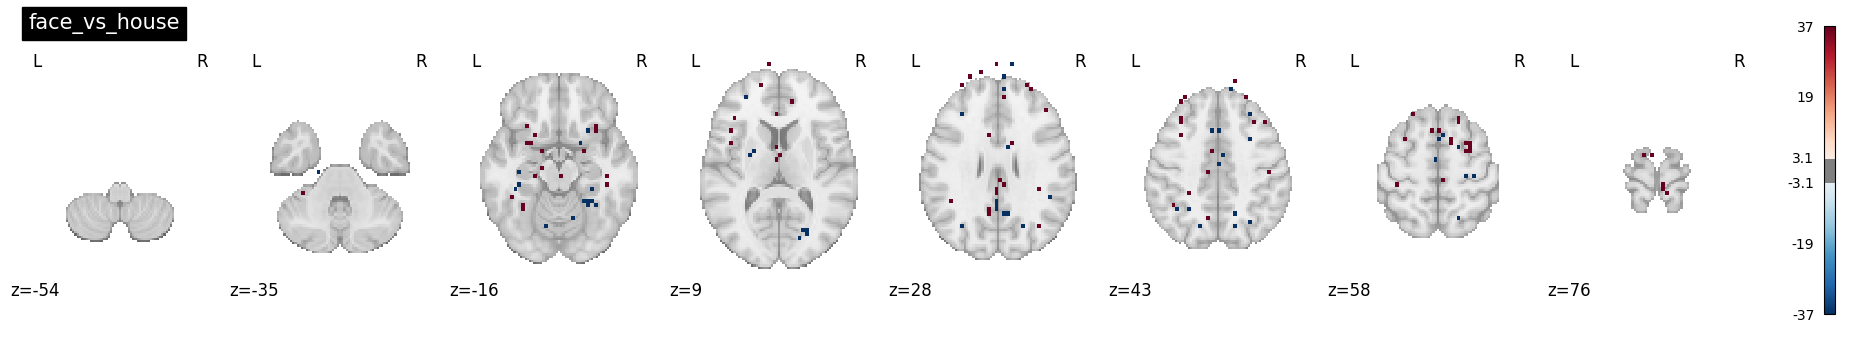

Running: face_vs_scrambled


/usr/local/lib/python3.12/dist-packages/nilearn/glm/model.py:205: RuntimeWarning: invalid value encountered in sqrt
  sd = np.sqrt(self.vcov(matrix=matrix, dispersion=dispersion))
/usr/local/lib/python3.12/dist-packages/nilearn/glm/_utils.py:207: RuntimeWarning: divide by zero encountered in divide
  return np.where(X <= 0, 0, 1.0 / X)
/tmp/ipykernel_3695/3720482581.py:9: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  fig = plot_stat_map(


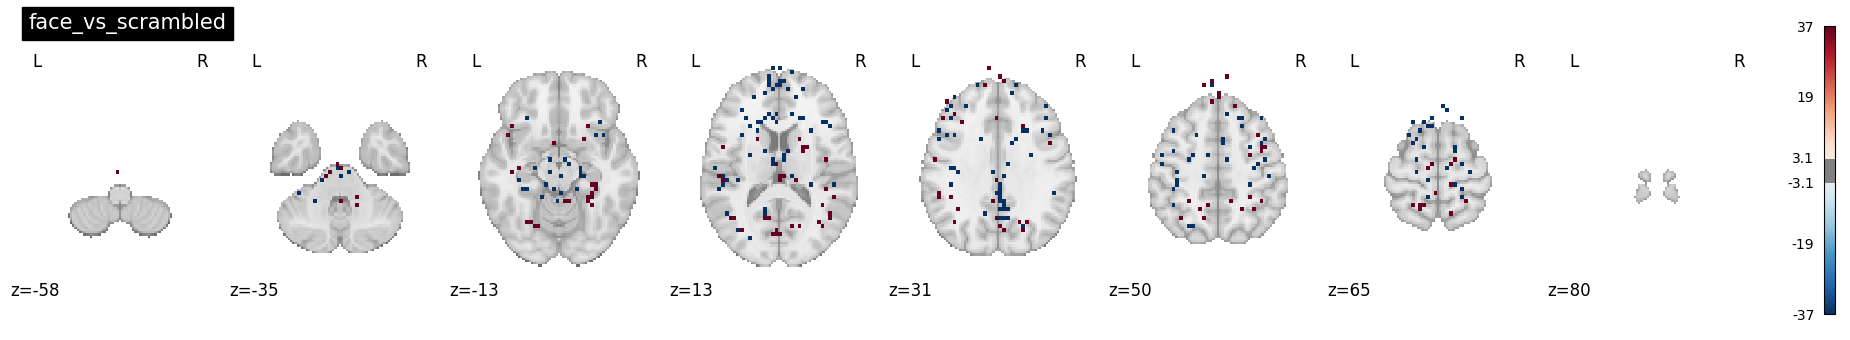

Running: house_vs_scrambled


/usr/local/lib/python3.12/dist-packages/nilearn/glm/model.py:205: RuntimeWarning: invalid value encountered in sqrt
  sd = np.sqrt(self.vcov(matrix=matrix, dispersion=dispersion))
/usr/local/lib/python3.12/dist-packages/nilearn/glm/_utils.py:207: RuntimeWarning: divide by zero encountered in divide
  return np.where(X <= 0, 0, 1.0 / X)
/tmp/ipykernel_3695/3720482581.py:9: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  fig = plot_stat_map(


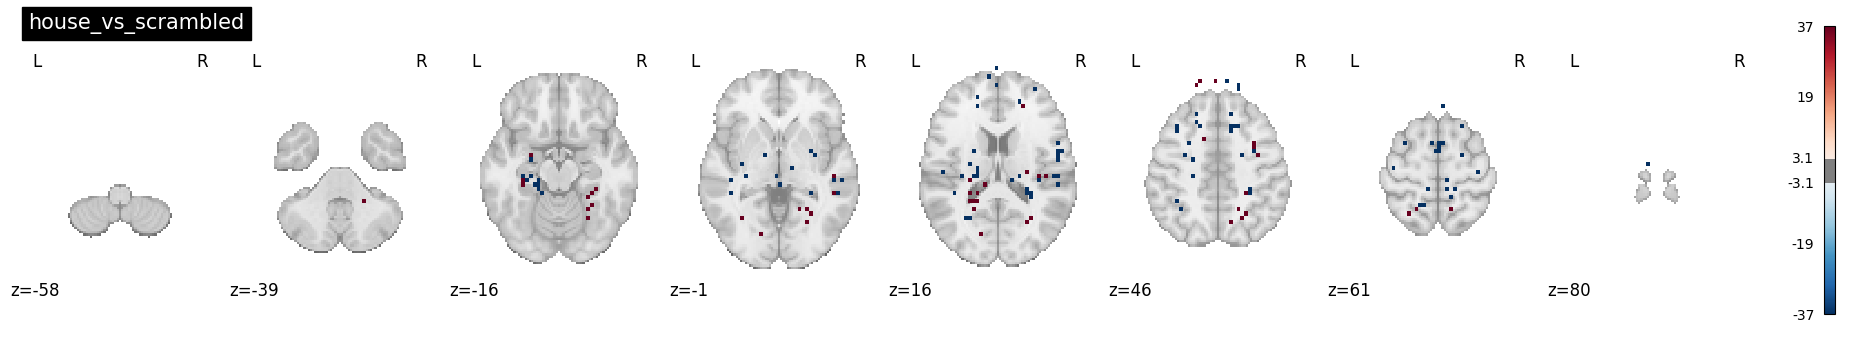

Running: cat_vs_bottle


/usr/local/lib/python3.12/dist-packages/nilearn/glm/model.py:205: RuntimeWarning: invalid value encountered in sqrt
  sd = np.sqrt(self.vcov(matrix=matrix, dispersion=dispersion))
/usr/local/lib/python3.12/dist-packages/nilearn/glm/_utils.py:207: RuntimeWarning: divide by zero encountered in divide
  return np.where(X <= 0, 0, 1.0 / X)
/tmp/ipykernel_3695/3720482581.py:9: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  fig = plot_stat_map(


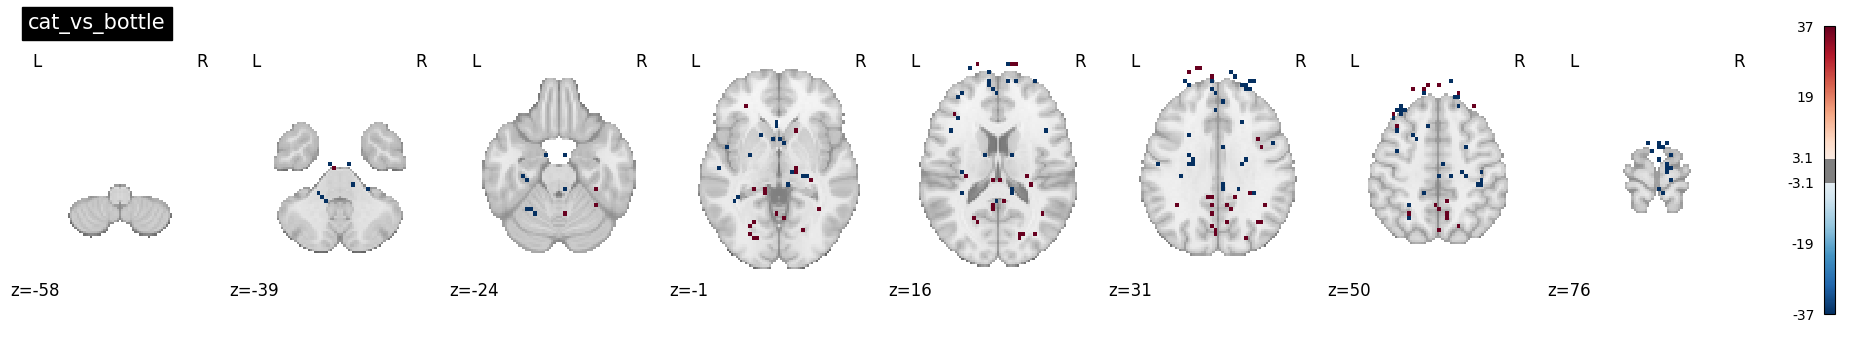

In [23]:
for name, formula in contrasts.items():
    print("Running:", name)

    z_map = glm.compute_contrast(
        formula,
        output_type="z_score"
    )

    fig = plot_stat_map(
        z_map,
        threshold=3.1,
        display_mode="z",
        cut_coords=8,
        title=name
    )

    fig.savefig(f"figures/{name}.png")
    plt.show()

In [24]:
print("Completed contrasts:")
for name in contrasts.keys():
    print("-", name)

Completed contrasts:
- face_vs_house
- face_vs_scrambled
- house_vs_scrambled
- cat_vs_bottle
